# Automated Anomaly Explanation with Counterfactuals
## Notebook 01: Data Understanding & Exploratory Data Analysis (EDA)

### Task Objective & Governing Constraints (PRD & SRS)
This notebook establishes the foundational data understanding for the **Automated Anomaly Explanation with Counterfactuals** project.
All analysis here strictly aligns with the governing requirements specified in `docs/PRD.md` and `docs/SRS.md`.

#### Governing Principles:
1. **Domain Context**: The prototype addresses an **industrial predictive-maintenance** decision-support problem using the AI4I 2020 Predictive Maintenance Dataset.
2. **Anomaly Detection Approach**: The downstream model (Isolation Forest) will be trained primarily on **normal operational data** (`Machine failure == 0`) to model the baseline envelope of healthy machine behavior.
3. **Counterfactual Requirements**:
   - Counterfactual recommendations must be **actionable, feasible, and plausible**.
   - **Feature Mutability**: Only actionable operating parameters (e.g., rotational speed, load/torque) may be modified. Immutable characteristics (e.g., machine identifiers, product quality types) must remain unchanged.
   - **Valid Ranges**: Counterfactuals must strictly respect realistic physical and observed operating bounds discovered from this data.
4. **Data Leakage Prevention**:
   - **Known Failure Labels** (`Machine failure`, `TWF`, `HDF`, `PWF`, `OSF`, `RNF`) represent downstream breakdown outcomes and ground-truth failure types. They **must NOT** be fed into the anomaly detector as input features. They are strictly reserved for post-hoc validation, benchmark evaluation, and normal-data splitting.
   - **Identifiers** (`UDI`, `Product ID`) are arbitrary sequence indexes or serialized inventory tags and **must NOT** be used as model inputs.
5. **Non-Destructive EDA**: This notebook accesses the raw CSV safely without altering, renaming, or mutating the original source file.

---
*Why this step matters for counterfactual generation:*
A counterfactual algorithm needs a mathematical search space defined by clear variable types, realistic boundaries $[min, max]$, and known mutability constraints. Inspecting the actual raw data is the only safe way to define these boundaries without ungrounded assumptions.

In [5]:
# Environment setup and imports
# We use standard data science libraries: pandas, numpy, matplotlib, and pathlib
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plotting styling for clarity and readability
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11

# Pandas display formatting for clean tabular inspection
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Safe Data Ingestion

In accordance with PRD Section 6 and SRS FR-01:
- The dataset must be loaded safely from `data/raw/`.
- The raw source file must remain unaltered.
- File existence, read accessibility, file size, and loading status must be verified before analysis.

In [6]:
# Locate raw data file and verify accessibility
data_path = pathlib.Path("../data/raw/ai4i2020.csv")
if not data_path.exists():
    # Fallback if working directory is repository root
    data_path = pathlib.Path("data/raw/ai4i2020.csv")

assert data_path.exists(), f"ERROR: Raw dataset not found at {data_path.resolve()}"

file_size_kb = data_path.stat().st_size / 1024
print(f"Source file found: {data_path}")
print(f"File size: {file_size_kb:.2f} KB ({data_path.stat().st_size} bytes)")

# Read CSV into memory without modifying the source file
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded into memory. Total records: {len(df):,}")

Source file found: ..\data\raw\ai4i2020.csv
File size: 509.81 KB (522048 bytes)
Dataset successfully loaded into memory. Total records: 10,000


## 2. Dataset Structure & Schema Verification

In this step (SRS FR-01 and FR-02), we inspect:
- Dataset dimensions (rows and columns);
- Exact column names (preserving original casing and units);
- Inferred pandas data types;
- Initial and trailing sample records.

*Why this is important:*
Accurate column names (including physical unit annotations like `[K]`, `[rpm]`, `[Nm]`, `[min]`) provide direct physical context for feature scaling, range checks, and human-readable counterfactual explanations.

In [7]:
# Inspect dataset dimensions and schema
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

print("--- Column Names and Data Types ---")
schema_summary = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values
})
print(schema_summary.to_string(index=False))

print("\n--- First 5 Records ---")
display_cols = list(df.columns)
print(df.head(5).to_string())

print("\n--- Last 3 Records ---")
print(df.tail(3).to_string())

Dataset Shape: 10000 rows x 14 columns

--- Column Names and Data Types ---
            Column Name Data Type  Non-Null Count
                    UDI     int64           10000
             Product ID       str           10000
                   Type       str           10000
    Air temperature [K]   float64           10000
Process temperature [K]   float64           10000
 Rotational speed [rpm]     int64           10000
            Torque [Nm]   float64           10000
        Tool wear [min]     int64           10000
        Machine failure     int64           10000
                    TWF     int64           10000
                    HDF     int64           10000
                    PWF     int64           10000
                    OSF     int64           10000
                    RNF     int64           10000

--- First 5 Records ---
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF

## 3. Data Quality & Integrity Inspection

In this step (SRS FR-02 and FR-03), we evaluate:
- Missing value counts and percentages across all attributes;
- Duplicate rows check;
- Column name collisions or duplicate column names;
- Any anomalies in basic record integrity.

*Why this is important:*
Counterfactual generators cannot produce valid recommendations on corrupted or undefined feature inputs. Knowing missingness patterns early dictates whether imputation is required during preprocessing.

In [8]:
# Check for missing values and duplicates
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
duplicate_rows = df.duplicated().sum()
duplicate_cols = len(df.columns) - len(set(df.columns))

quality_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct
})

print("--- Missing Values Summary ---")
print(quality_df.to_string())
print(f"\nTotal Missing Values Across Dataset: {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {duplicate_rows}")
print(f"Duplicate Column Names Detected: {duplicate_cols}")

if df.isnull().sum().sum() == 0 and duplicate_rows == 0:
    print("\n[DATA QUALITY ASSESSMENT]: The raw dataset has zero missing values and zero duplicate rows. Clean integrity.")

--- Missing Values Summary ---
                         Missing Count  Missing Percentage (%)
UDI                                  0                   0.000
Product ID                           0                   0.000
Type                                 0                   0.000
Air temperature [K]                  0                   0.000
Process temperature [K]              0                   0.000
Rotational speed [rpm]               0                   0.000
Torque [Nm]                          0                   0.000
Tool wear [min]                      0                   0.000
Machine failure                      0                   0.000
TWF                                  0                   0.000
HDF                                  0                   0.000
PWF                                  0                   0.000
OSF                                  0                   0.000
RNF                                  0                   0.000

Total Missing Values Ac

## 4. Numerical Feature Inspection: Descriptive Statistics & Physical Bounds

The dataset includes 5 physical operational measurements:
1. `Air temperature [K]`: Ambient shop temperature in Kelvin.
2. `Process temperature [K]`: Cutting zone / process temperature in Kelvin.
3. `Rotational speed [rpm]`: Spindle rotation speed in revolutions per minute.
4. `Torque [Nm]`: Motor torque applied to the cutting tool in Newton-meters.
5. `Tool wear [min]`: Cumulative active cutting time of the current tool in minutes.

*Why this is important for Counterfactual Generation:*
- **Observed Range Bounds $[min, max]$**: A counterfactual must NEVER suggest an unphysical parameter (e.g. negative torque, rotational speed beyond motor limits, or negative tool wear).
- **Distribution Spread & Scales**: Features operate on vastly different numerical scales (e.g. Torque ~ 40 Nm vs Speed ~ 1500 rpm). This confirms that feature normalization/scaling will be essential prior to distance-based counterfactual search.

In [9]:
# Define operational numerical features
numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Calculate descriptive statistics and observed data ranges
stats_df = df[numerical_features].describe().T
stats_df['range_span'] = stats_df['max'] - stats_df['min']
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
stats_df['skew'] = df[numerical_features].skew()

stats_summary = stats_df[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range_span', 'IQR', 'skew']]
print("--- Operational Numerical Features: Summary Statistics & Observed Data Ranges ---")
print(stats_summary.to_string())

--- Operational Numerical Features: Summary Statistics & Observed Data Ranges ---
                            count     mean     std      min      25%      50%      75%      max  range_span     IQR   skew
Air temperature [K]     10000.000  300.005   2.000  295.300  298.300  300.100  301.500  304.500       9.200   3.200  0.114
Process temperature [K] 10000.000  310.006   1.484  305.700  308.800  310.100  311.100  313.800       8.100   2.300  0.015
Rotational speed [rpm]  10000.000 1538.776 179.284 1168.000 1423.000 1503.000 1612.000 2886.000    1718.000 189.000  1.993
Torque [Nm]             10000.000   39.987   9.969    3.800   33.200   40.100   46.800   76.600      72.800  13.600 -0.010
Tool wear [min]         10000.000  107.951  63.654    0.000   53.000  108.000  162.000  253.000     253.000 109.000  0.027


## 5. Categorical & Identifier Feature Analysis

Three non-sensor columns are present:
- `UDI`: Universal Unique Identifier (integer 1 to 10000).
- `Product ID`: Serialized product identifier containing variant prefix ('L', 'M', 'H') followed by sequence digits.
- `Type`: Nominal product quality variant ('L' for Low, 'M' for Medium, 'H' for High).

*Why this is important for Counterfactual Generation:*
- `UDI` and `Product ID` are arbitrary inventory tags. Changing a product ID does not fix a physical anomaly! They must be classified as **Identifiers** and excluded from the model.
- `Type` represents product variant quality (50% L, 30% M, 20% H). While it is a machine attribute, an operator cannot change a physical part variant mid-cut. Thus, `Type` is either excluded or classified as **Immutable**.

In [10]:
# Analyze identifiers and categorical features
udi_unique = df['UDI'].nunique()
pid_unique = df['Product ID'].nunique()
type_counts = df['Type'].value_counts()
type_proportions = df['Type'].value_counts(normalize=True) * 100

print(f"UDI Cardinality: {udi_unique} unique values out of {len(df)} rows (100% unique row index)")
print(f"Product ID Cardinality: {pid_unique} unique values out of {len(df)} rows (100% unique part identifier)")

print("\n--- Product Type Breakdown ---")
type_summary = pd.DataFrame({
    'Count': type_counts,
    'Percentage (%)': type_proportions
})
print(type_summary.to_string())

# Verify consistency between Product ID prefix and Type column
pid_prefix_matches = (df['Product ID'].str[0] == df['Type']).all()
print(f"\nDoes Product ID prefix strictly match Type column for all rows? {pid_prefix_matches}")

UDI Cardinality: 10000 unique values out of 10000 rows (100% unique row index)
Product ID Cardinality: 10000 unique values out of 10000 rows (100% unique part identifier)

--- Product Type Breakdown ---
      Count  Percentage (%)
Type                       
L      6000          60.000
M      2997          29.970
H      1003          10.030

Does Product ID prefix strictly match Type column for all rows? True


## 6. Ground-Truth Target & Failure Modes Analysis

The dataset provides 6 failure-related columns:
- `Machine failure`: Binary overall failure indicator (1 = failure, 0 = normal).
- Specific failure modes:
  1. `TWF` (Tool Wear Failure): Tool wears out beyond failure limit.
  2. `HDF` (Heat Dissipation Failure): Inadequate heat dissipation ($\Delta T < 8.6\text{ K}$ and speed $< 1380\text{ rpm}$).
  3. `PWF` (Power Failure): Electric motor power ($P = \text{Torque} \times \omega$) falls outside allowed operating power envelope ($< 3500\text{ W}$ or $> 9000\text{ W}$).
  4. `OSF` (Overstrain Failure): Product of tool wear and torque exceeds variant limit.
  5. `RNF` (Random Failure): Independent stochastic failure ($p = 0.001$).

*Why this is important for Anomaly Detection & Counterfactuals:*
- The overall failure rate (~3.39%) aligns with typical industrial anomaly detection scenarios where normal operations vastly outnumber anomalies.
- Isolation Forest will be trained primarily on the 96.61% **Normal** cases (`Machine failure == 0`).
- The 339 failure records serve as authentic anomalous test candidates to evaluate whether counterfactual recommendations flip detector decisions from Anomaly to Normal.

In [11]:
# Target distribution and failure mode analysis
target_counts = df['Machine failure'].value_counts()
target_pct = df['Machine failure'].value_counts(normalize=True) * 100

print("--- Known Machine-Failure Label Distribution ---")
for val in [0, 1]:
    label = (
        "Known normal operation (Machine failure = 0)"
        if val == 0
        else "Known machine failure (Machine failure = 1)"
    )
    print(f"  Class {val} ({label}): {target_counts[val]:,d} observations ({target_pct[val]:.2f}%)")

failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_mode_total = df[failure_modes].sum(axis=1)
fm_counts = df[failure_modes].sum()
fm_pct = (fm_counts / len(df)) * 100

print("\n--- Specific Failure Modes Breakdown ---")
fm_summary = pd.DataFrame({
    'Failure Mode': failure_modes,
    'Occurrences': fm_counts.values,
    'Dataset Percentage (%)': fm_pct.values,
    'Description': [
        'Tool Wear Failure',
        'Heat Dissipation Failure',
        'Power Failure',
        'Overstrain Failure',
        'Random Failure'
    ]
})
print(fm_summary.to_string(index=False))

multi_failures = (failure_mode_total > 1).sum()
print(f"\nMulti-failure observations (two or more concurrent failure modes): {multi_failures}")

mismatch_1 = ((df['Machine failure'] == 1) & (failure_mode_total == 0)).sum()
mismatch_2 = ((df['Machine failure'] == 0) & (failure_mode_total > 0)).sum()

print(f"Records with Machine failure == 1 but zero specific failure modes: {mismatch_1}")
print(f"Records with Machine failure == 0 but at least one failure-mode flag: {mismatch_2}")

if mismatch_2 > 0:
    sub_mismatch = df[(df['Machine failure'] == 0) & (failure_mode_total > 0)]
    print(f"  -> Failure-mode flags when Machine failure == 0: {sub_mismatch[failure_modes].sum().to_dict()}")
    print("  -> Note: RNF is a dataset label and does not always correspond to a machine-failure shutdown flag.")

--- Known Machine-Failure Label Distribution ---
  Class 0 (Known normal operation (Machine failure = 0)): 9,661 observations (96.61%)
  Class 1 (Known machine failure (Machine failure = 1)): 339 observations (3.39%)

--- Specific Failure Modes Breakdown ---
Failure Mode  Occurrences  Dataset Percentage (%)              Description
         TWF           46                   0.460        Tool Wear Failure
         HDF          115                   1.150 Heat Dissipation Failure
         PWF           95                   0.950            Power Failure
         OSF           98                   0.980       Overstrain Failure
         RNF           19                   0.190           Random Failure

Multi-failure observations (two or more concurrent failure modes): 24
Records with Machine failure == 1 but zero specific failure modes: 9
Records with Machine failure == 0 but at least one failure-mode flag: 18
  -> Failure-mode flags when Machine failure == 0: {'TWF': 0, 'HDF': 0, 'PWF':

## 7. Feature Distributions: Normal vs. Anomaly Operating Regimes

We now visualize the distributions of each operational numerical feature, comparing **Normal Operations** (`Machine failure == 0`) with **Anomalous Failure Cases** (`Machine failure == 1`).

*Why this is important for Counterfactual Generation:*
- Identifies where anomalous observations deviate from normal density regions.
- Shows what physical adjustments (e.g. reducing torque, increasing speed, or lowering temperature) move an observation toward high-density normal operating zones.

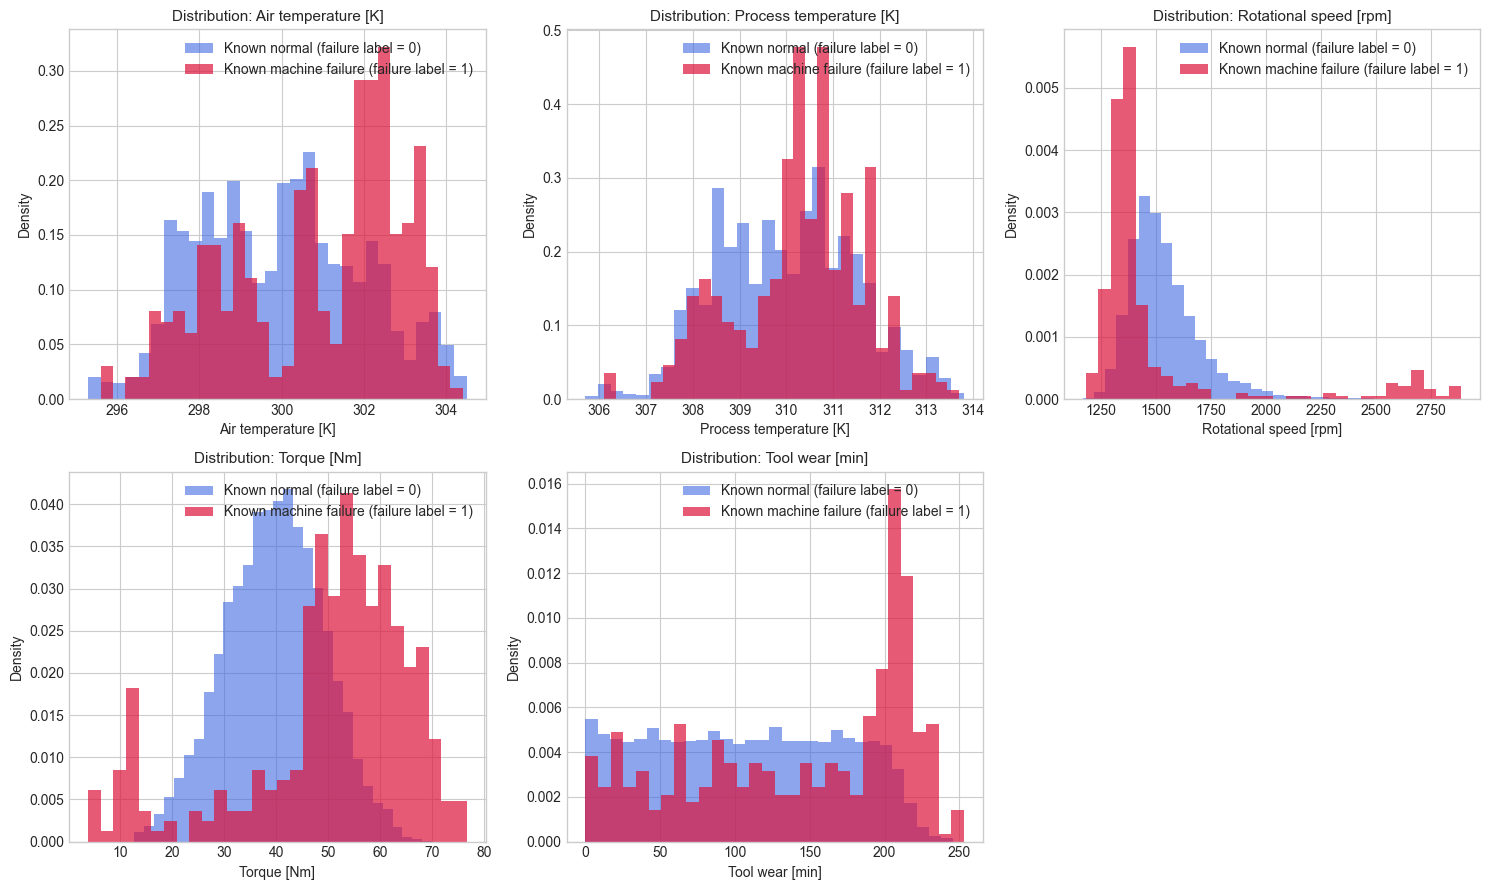

--- Mean Feature Comparison: Normal vs Anomaly ---
                         Known Normal Mean  Known Failure Mean  Absolute Shift  Relative Shift (%)
Air temperature [K]                299.974             300.886           0.912               0.304
Process temperature [K]            309.996             310.290           0.295               0.095
Rotational speed [rpm]            1540.260            1496.487         -43.773              -2.842
Torque [Nm]                         39.630              50.168          10.538              26.592
Tool wear [min]                    106.694             143.782          37.088              34.761


In [12]:
# Plot distributions of numerical features comparing known normal vs known machine-failure records
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    ax = axes[idx]
    normal_data = df[df['Machine failure'] == 0][col]
    known_failure_data = df[df['Machine failure'] == 1][col]
    
    ax.hist(normal_data, bins=30, alpha=0.6, density=True, color='royalblue', label='Known normal (failure label = 0)')
    ax.hist(known_failure_data, bins=30, alpha=0.7, density=True, color='crimson', label='Known machine failure (failure label = 1)')
    
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(loc='upper right')

# Remove unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# Mean comparison table
mean_comp = pd.DataFrame({
    'Known Normal Mean': df[df['Machine failure'] == 0][numerical_features].mean(),
    'Known Failure Mean': df[df['Machine failure'] == 1][numerical_features].mean(),
    'Absolute Shift': (df[df['Machine failure'] == 1][numerical_features].mean() - df[df['Machine failure'] == 0][numerical_features].mean()),
    'Relative Shift (%)': ((df[df['Machine failure'] == 1][numerical_features].mean() - df[df['Machine failure'] == 0][numerical_features].mean()) / df[df['Machine failure'] == 0][numerical_features].mean()) * 100
})
print("--- Mean Feature Comparison: Normal vs Anomaly ---")
print(mean_comp.to_string())

## 8. Boxplot Analysis & Outlier Detection across Machine States

Boxplots reveal the median, interquartile range (IQR), and extreme operational points for each feature.

*Key observations to look for:*
- Extreme torque and low rotational speed associated with Power and Overstrain failures.
- Elevated tool wear in failure cases (confirming that excessive tool wear drives degradation).

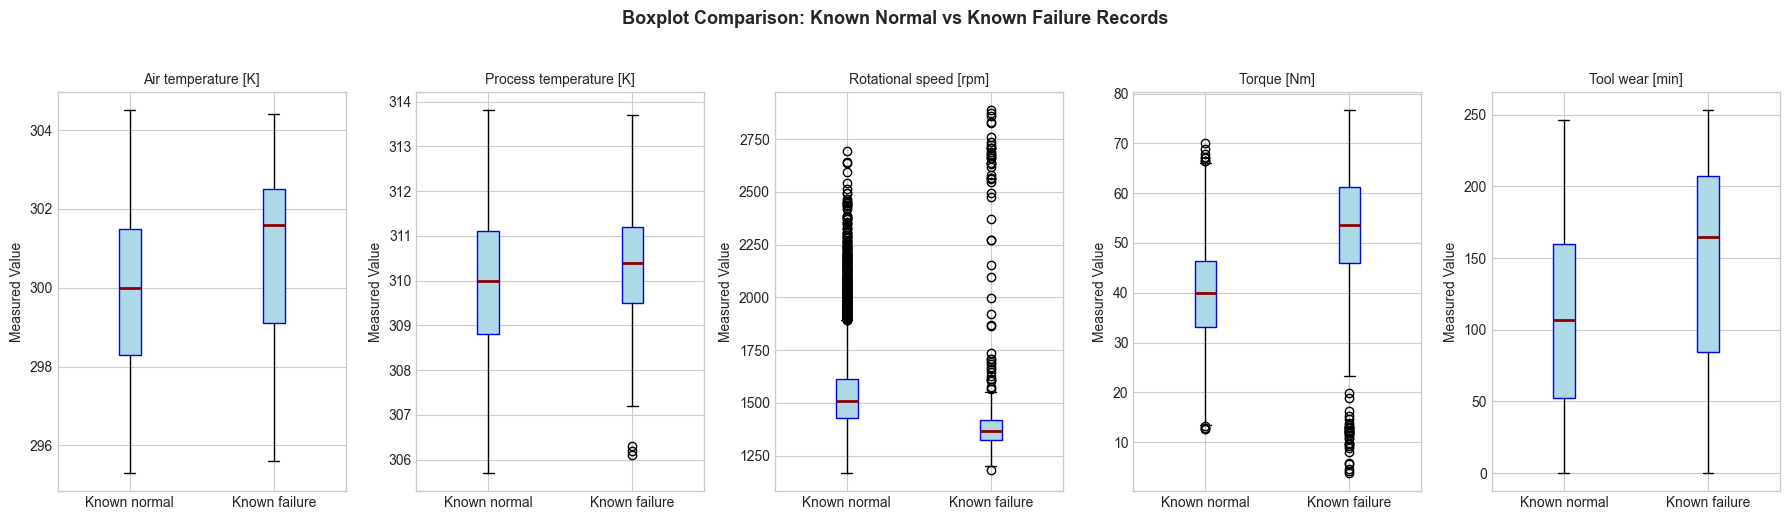

In [13]:
# Generate boxplots for operational features grouped by Machine failure
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, col in enumerate(numerical_features):
    ax = axes[idx]
    data_to_plot = [
        df[df['Machine failure'] == 0][col],
        df[df['Machine failure'] == 1][col]
    ]
    ax.boxplot(data_to_plot, tick_labels=['Known normal', 'Known failure'], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='darkred', linewidth=2))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Measured Value")

plt.suptitle("Boxplot Comparison: Known Normal vs Known Failure Records", y=1.03, fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Interdependence & Physical Coupling

Machine operations are governed by physical laws:
- **Torque and Rotational Speed**: In an electric motor, power is proportional to Torque $\times$ Speed. These two features typically exhibit a strong inverse non-linear relationship.
- **Air Temperature and Process Temperature**: Heat generated during cutting causes Process Temperature to rise above ambient Air Temperature.

*Why this is important for Plausibility:*
A counterfactual generator cannot change features independently without considering their physical relationships. For example, suggesting maximum torque AND maximum rotational speed simultaneously would cause an unphysical power overload. The plausibility check (SRS FR-11) will ensure counterfactuals adhere to realistic joint configurations.

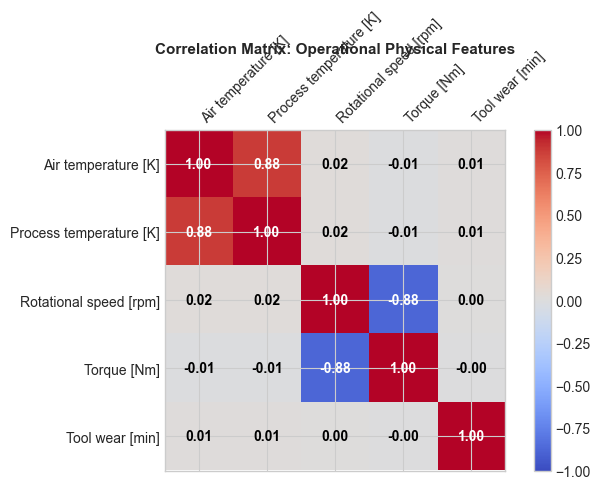

Key Observed Correlations:
1. Rotational Speed vs Torque: -0.875 — strong negative correlation; consistent with a motor torque-speed relationship, but not proof of a physical rule.
2. Air Temperature vs Process Temperature: 0.876 — strong positive correlation; consistent with thermal coupling, but not proof of a physical rule.


In [14]:
# Correlation analysis among operational features
corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(7, 5))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ticks = np.arange(len(numerical_features))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(numerical_features, rotation=45, ha='left')
ax.set_yticklabels(numerical_features)

# Annotate correlation values inside matrix cells
for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontweight='bold')

plt.title("Correlation Matrix: Operational Physical Features", y=1.2, weight='bold')
plt.tight_layout()
plt.show()

print("Key Observed Correlations:")

speed_torque_corr = corr_matrix.loc['Rotational speed [rpm]', 'Torque [Nm]']
air_process_corr = corr_matrix.loc['Air temperature [K]', 'Process temperature [K]']

print(f"1. Rotational Speed vs Torque: {speed_torque_corr:.3f} — strong negative correlation; consistent with a motor torque-speed relationship, but not proof of a physical rule.")

print(f"2. Air Temperature vs Process Temperature: {air_process_corr:.3f} — strong positive correlation; consistent with thermal coupling, but not proof of a physical rule.")

## 10. Explicit Data Leakage Investigation & Role Classification

In accordance with PRD Section 7 and SRS FR-04:
We must explicitly investigate every column for potential target leakage or non-physical correlation.

### Leakage Analysis Matrix:
| Column Name | Category | Potential Leakage Risk | Decision & Justification |
| :--- | :--- | :--- | :--- |
| `UDI` | Row Counter (1..10000) | Low predictive leakage, high overfitting risk | **EXCLUDE (Identifier)**: Arbitrary row sequence; contains no physical operational information. |
| `Product ID` | Serial Number (e.g. L47181) | High cardinality index | **EXCLUDE (Identifier)**: Serial number; unique per part; variant type is captured in `Type`. |
| `Type` | Categorical (L, M, H) | None | **CANDIDATE / IMMUTABLE**: Product quality tier. An operator cannot change workpiece material mid-operation. |
| `Air temperature [K]` | Numerical Sensor | None | **CANDIDATE MODEL INPUT**: Ambient operational temperature. |
| `Process temperature [K]` | Numerical Sensor | None | **CANDIDATE MODEL INPUT**: Cutting temperature. |
| `Rotational speed [rpm]` | Numerical Actuator | None | **CANDIDATE MODEL INPUT**: Controllable CNC spindle speed. |
| `Torque [Nm]` | Numerical Sensor/Load | None | **CANDIDATE MODEL INPUT**: Cutting torque / motor load. |
| `Tool wear [min]` | Numerical Degradation | None | **CANDIDATE MODEL INPUT**: Cumulative cutting time. |
| `Machine failure` | Binary Target (0/1) | **CRITICAL DIRECT TARGET LEAKAGE** | **EXCLUDE FROM MODEL (Evaluation Label)**: Ground-truth anomaly label. Must only be used for evaluation and training-set filtering (`Machine failure == 0`). |
| `TWF` | Failure Mode Indicator | **CRITICAL DIRECT TARGET LEAKAGE** | **EXCLUDE FROM MODEL (Evaluation Label)**: Direct failure mode flag. |
| `HDF` | Failure Mode Indicator | **CRITICAL DIRECT TARGET LEAKAGE** | **EXCLUDE FROM MODEL (Evaluation Label)**: Direct failure mode flag. |
| `PWF` | Failure Mode Indicator | **CRITICAL DIRECT TARGET LEAKAGE** | **EXCLUDE FROM MODEL (Evaluation Label)**: Direct failure mode flag. |
| `OSF` | Failure Mode Indicator | **CRITICAL DIRECT TARGET LEAKAGE** | **EXCLUDE FROM MODEL (Evaluation Label)**: Direct failure mode flag. |
| `RNF` | Failure Mode Indicator | **CRITICAL DIRECT TARGET LEAKAGE** | **EXCLUDE FROM MODEL (Evaluation Label)**: Direct failure mode flag. |

In [15]:
# Programmatic verification of feature roles
identifier_cols = ['UDI', 'Product ID']
label_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
candidate_feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

all_accounted_for = set(identifier_cols + label_cols + candidate_feature_cols) == set(df.columns)
print(f"Are all 14 dataset columns accounted for in our role classification? {all_accounted_for}")
print(f"\nIdentifiers ({len(identifier_cols)}): {identifier_cols}")
print(f"Known Evaluation Labels ({len(label_cols)}): {label_cols}")
print(f"Candidate Model Features ({len(candidate_feature_cols)}): {candidate_feature_cols}")

Are all 14 dataset columns accounted for in our role classification? True

Identifiers (2): ['UDI', 'Product ID']
Known Evaluation Labels (6): ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Candidate Model Features (6): ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


## 11. EDA Findings to Confirm

This final section synthesizes all evidence from the AI4I 2020 dataset inspection to guide the subsequent preprocessing, anomaly detection, and counterfactual design steps (PRD Section 14, SRS FR-03 & FR-04).

### 1. Proposed Identifier Columns
- `UDI`: Arbitrary sequence counter (1 to 10,000). Must be dropped from model input features.
- `Product ID`: Unique part serial number (e.g., L47181, M14860). Must be dropped from model input features.

### 2. Proposed Known Label / Evaluation Columns
- `Machine failure`: Primary ground-truth binary outcome (0 = Normal, 1 = Failure).
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: Five specific failure mode labels.
- **Role**: Strictly reserved for:
  1. Splitting the dataset to train the unsupervised Isolation Forest primarily on normal operations (`Machine failure == 0`).
  2. Benchmarking the detector's anomaly detection performance (Precision, Recall, F1).
  3. Selecting anomalous test cases for counterfactual evaluation.

### 3. Proposed Candidate Model-Input Features
- **Core Numerical Features (5 continuous)**:
  1. `Air temperature [K]`
  2. `Process temperature [K]`
  3. `Rotational speed [rpm]`
  4. `Torque [Nm]`
  5. `Tool wear [min]`
- **Optional Categorical Feature (1 nominal)**:
  - `Type` ('L', 'M', 'H') representing product variant quality tier.

### 4. Proposed Feature Types
- **Numerical (Continuous/Discrete)**:
  - `Air temperature [K]`: Float (continuous)
  - `Process temperature [K]`: Float (continuous)
  - `Rotational speed [rpm]`: Integer/Float (continuous)
  - `Torque [Nm]`: Float (continuous)
  - `Tool wear [min]`: Integer (continuous degradation)
- **Categorical (Nominal)**:
  - `Type`: String category with 3 levels: 'L' (60.0%), 'M' (29.97%), 'H' (10.03%).

### 5. Observed Physical Feature Ranges (Hard Bounds for Counterfactuals)
Counterfactuals must be strictly bounded within these empirical limits:
- `Air temperature [K]`: **[295.300, 304.500]** (Span: 9.200 K)
- `Process temperature [K]`: **[305.700, 313.800]** (Span: 8.100 K)
- `Rotational speed [rpm]`: **[1168, 2886]** (Span: 1718 rpm)
- `Torque [Nm]`: **[3.800, 76.600]** (Span: 72.800 Nm)
- `Tool wear [min]`: **[0, 253]** (Span: 253 min)

### 6. Mutability Classification Hypothesis
In accordance with PRD Section 7 and SRS FR-08 / FR-10:
- **Mutable Operational Parameters (Directly Actionable)**:
  - `Rotational speed [rpm]`: Machine operator can readily adjust spindle speed settings via CNC controller.
  - `Torque [Nm]`: Controllable via cutting feed rate, depth of cut, and spindle speed.
- **Conditionally Mutable / Coupled Parameters**:
  - `Process temperature [K]`: Driven by cutting friction and coolant flow; partially mutable through coolant adjustment or speed reduction.
  - `Air temperature [K]`: Ambient shop temperature; largely driven by ambient HVAC; low immediate mutability for an individual machine.
- **Monotonic / Discrete Intervention**:
  - `Tool wear [min]`: Physical wear accumulates monotonically and cannot decrease during active cutting. A counterfactual cannot suggest reducing tool wear by 10 minutes; it can only suggest a discrete maintenance intervention (tool replacement, resetting tool wear to 0 min).
- **Immutable Attributes**:
  - `Type`: Fixed by the production order. A machine milling a Type 'L' part cannot arbitrarily change the part to 'H' mid-run.

### 7. Missing-Data Handling Considerations
- The raw dataset contains **zero missing values** across all 10,000 records.
- Preprocessing does not require imputation for training. However, the inference pipeline (`src/preprocessing.py`) must include validation assertions that reject incoming records with missing values.

### 8. Unresolved Questions for Human Confirmation Prior to Preprocessing
Before implementing `src/preprocessing.py` and `src/detector.py`, the following engineering decisions should be confirmed:
1. **Should `Type` be included as an input feature or excluded?**
   - *Option A (Recommended)*: Exclude `Type` from the initial Isolation Forest baseline and use only the 5 continuous physical sensors. This avoids one-hot encoding complexity and keeps counterfactual generation purely focused on physical operational adjustments.
   - *Option B*: One-hot encode `Type` into `Type_L`, `Type_M`, `Type_H`, but mark all three as strictly **immutable** in `config/features.yaml`.
2. **How should `Tool wear [min]` be treated during counterfactual search?**
   - *Option A (Recommended)*: Treat `Tool wear [min]` as immutable during immediate operational setpoint adjustments (changing speed and torque only).
   - *Option B*: Allow a discrete "maintenance reset" action where tool wear can be set to 0.
3. **Training Data Split Strategy for Isolation Forest**:
   - *Option A (Recommended)*: Train Isolation Forest exclusively on the 9,661 normal cases (`Machine failure == 0`), reserving the 339 failure cases for evaluation and counterfactual validation.
   - *Option B*: Train on the full dataset with a contaminated contamination parameter ($pprox 0.034$).
4. **Handling of the 18 RNF cases with Machine failure == 0**:
   - Should these 18 observations be retained in normal training data or excluded as potential anomalies?

In [16]:
# Create and display the finalized feature specification table
findings_data = [
    {"Feature / Column": "UDI", "Role": "Identifier", "Type": "Integer", "Observed Range": "[1, 10000]", "Mutability": "Excluded", "Action in Pipeline": "Drop from model input"},
    {"Feature / Column": "Product ID", "Role": "Identifier", "Type": "String", "Observed Range": "10000 unique strings", "Mutability": "Excluded", "Action in Pipeline": "Drop from model input"},
    {"Feature / Column": "Type", "Role": "Candidate Feature / Metadata", "Type": "Categorical (L, M, H)", "Observed Range": "3 classes (L, M, H)", "Mutability": "Immutable", "Action in Pipeline": "Exclude in baseline or encode as immutable"},
    {"Feature / Column": "Air temperature [K]", "Role": "Model Input Feature", "Type": "Float (Continuous)", "Observed Range": f"[{df['Air temperature [K]'].min():.1f}, {df['Air temperature [K]'].max():.1f}]", "Mutability": "Low Mutability / Ambient", "Action in Pipeline": "Standardize/Scale"},
    {"Feature / Column": "Process temperature [K]", "Role": "Model Input Feature", "Type": "Float (Continuous)", "Observed Range": f"[{df['Process temperature [K]'].min():.1f}, {df['Process temperature [K]'].max():.1f}]", "Mutability": "Conditionally Mutable", "Action in Pipeline": "Standardize/Scale"},
    {"Feature / Column": "Rotational speed [rpm]", "Role": "Model Input Feature", "Type": "Integer (Continuous)", "Observed Range": f"[{df['Rotational speed [rpm]'].min():.0f}, {df['Rotational speed [rpm]'].max():.0f}]", "Mutability": "High Mutability (Direct CNC Setpoint)", "Action in Pipeline": "Standardize/Scale"},
    {"Feature / Column": "Torque [Nm]", "Role": "Model Input Feature", "Type": "Float (Continuous)", "Observed Range": f"[{df['Torque [Nm]'].min():.1f}, {df['Torque [Nm]'].max():.1f}]", "Mutability": "High Mutability (Controllable Load)", "Action in Pipeline": "Standardize/Scale"},
    {"Feature / Column": "Tool wear [min]", "Role": "Model Input Feature", "Type": "Integer (Continuous)", "Observed Range": f"[{df['Tool wear [min]'].min():.0f}, {df['Tool wear [min]'].max():.0f}]", "Mutability": "Monotonic / Replace-Only", "Action in Pipeline": "Standardize/Scale"},
    {"Feature / Column": "Machine failure", "Role": "Known Failure Label / Evaluation Proxy", "Type": "Binary (0/1)", "Observed Range": "0 (96.61%), 1 (3.39%)", "Mutability": "Excluded", "Action in Pipeline": "Evaluation proxy and normal-training-pool selection only; never model input"},
    {"Feature / Column": "TWF", "Role": "Failure Mode Label", "Type": "Binary (0/1)", "Observed Range": "46 occurrences (0.46%)", "Mutability": "Excluded", "Action in Pipeline": "Evaluation only"},
    {"Feature / Column": "HDF", "Role": "Failure Mode Label", "Type": "Binary (0/1)", "Observed Range": "115 occurrences (1.15%)", "Mutability": "Excluded", "Action in Pipeline": "Evaluation only"},
    {"Feature / Column": "PWF", "Role": "Failure Mode Label", "Type": "Binary (0/1)", "Observed Range": "95 occurrences (0.95%)", "Mutability": "Excluded", "Action in Pipeline": "Evaluation only"},
    {"Feature / Column": "OSF", "Role": "Failure Mode Label", "Type": "Binary (0/1)", "Observed Range": "98 occurrences (0.98%)", "Mutability": "Excluded", "Action in Pipeline": "Evaluation only"},
    {"Feature / Column": "RNF", "Role": "Failure Mode Label", "Type": "Binary (0/1)", "Observed Range": "19 occurrences (0.19%)", "Mutability": "Excluded", "Action in Pipeline": "Evaluation only"}
]

findings_summary_df = pd.DataFrame(findings_data)
print("=== FINAL FEATURE SPECIFICATION & EDA SUMMARY TABLE ===")
print(findings_summary_df.to_string(index=False))
print("\nEDA notebook execution complete. All findings ready for team confirmation.")

=== FINAL FEATURE SPECIFICATION & EDA SUMMARY TABLE ===
       Feature / Column                                   Role                  Type          Observed Range                            Mutability                                                          Action in Pipeline
                    UDI                             Identifier               Integer              [1, 10000]                              Excluded                                                       Drop from model input
             Product ID                             Identifier                String    10000 unique strings                              Excluded                                                       Drop from model input
                   Type           Candidate Feature / Metadata Categorical (L, M, H)     3 classes (L, M, H)                             Immutable                                  Exclude in baseline or encode as immutable
    Air temperature [K]                    Model Inp

## Interpretation Limits and Decisions Still Needed

- `Machine failure` is a known dataset failure label used for evaluation and for selecting the normal training pool. It is not the Isolation Forest prediction.
- Observed minimum and maximum values are empirical bounds from this dataset. They are not guaranteed physical safety limits.
- The EDA identifies candidate features but cannot prove which machine settings are controllable in a real factory.
- Before counterfactual generation, the project must explicitly confirm which features are mutable, immutable, or maintenance-only actions.
- The first baseline will use the five continuous operational features and exclude identifiers, `Type`, and all failure-label columns from model inputs.